Test the slab model with 2 islands. Fig.15 (c):
$$
\begin{align*}
&m_1=m_2=1\;,\;n_1=-n_2=1\\
&\delta_1=\delta_2 =0.5\\
&\iota'=2
\end{align*}
$$

In [1]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
from fields.slab_bfield_two_pert import SlabBfieldTwoPert
from pyoculus.maps import ToroidalBfieldSection
from pyoculus.solvers import PoincarePlot, FixedPoint
import matplotlib.pyplot as plt

#### Create the magnetic field:

In [2]:
field = SlabBfieldTwoPert(
    m1=1,
    n1=1,
    delta1=0.5,
    m2=1,
    n2=-1,
    delta2=0.5,
    iota_prime=2.0,
    x0=1.0,
)

xs1 = field.x0 + field.n1 / (field.iota_prime * field.m1)
xs2 = field.x0 + field.n2 / (field.iota_prime * field.m2)

print("The islands will be situated at x_s =", xs1, xs2)

The islands will be situated at x_s = 1.5 0.5


#### Create the map:

In [3]:
map = ToroidalBfieldSection(field, domain=[(0, 2), (0, 2*np.pi)])

#### Create Poincaré plot:

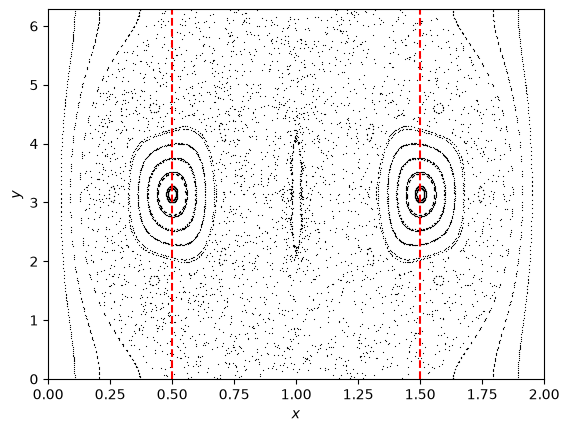

In [4]:
pplot = PoincarePlot.with_linspace(
    map,
    np.array([0.05, np.pi]),
    np.array([1.95, np.pi]),
    npts=50
)

# Follow each initial condition for 200 crossings
pplot.compute(npts=150)

# Plot directly in (x,y) coordinates
fig, ax = pplot.plot(plottype=None) # plottypeNone to directly plot in the coordinates of the map

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim(0, 2)
ax.set_ylim(0, 2*np.pi)

ax.axvline(
    xs1,
    linestyle="--",
    label=rf"$x_s1={xs1:.3f}$",
    color="r"
)
ax.axvline(
    xs2,
    linestyle="--",
    label=rf"$x_s2={xs2:.3f}$",
    color="r"
)
plt.show()

#### Find fixed points:

In [5]:
fp = FixedPoint(map)

[[1.         3.14159265]
 [1.         3.14159265]]
[[1.00000000e+00 6.28318531e+00]
 [1.00000000e+00 2.82982526e-11]]


(<Figure size 640x480 with 1 Axes>, <Axes: >)

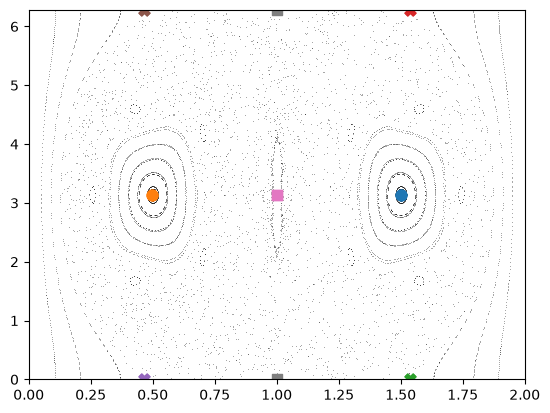

In [6]:
fig, ax = pplot.plot(
    s=0.5,
    xlim=[0, 2],
    ylim=[0, 2*np.pi],
    plottype=None
)


fp = FixedPoint(map)

# Elliptic fixed points / O-points:
result = fp.find_with_iota(
    n = field.n1,
    m = field.m1,
    guess = np.array([1.4, 3]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

result = fp.find_with_iota(
    n = field.n2,
    m = field.m2,
    guess = np.array([0.4, 3]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

# Hyperbolic fixed points / X-points:
result = fp.find_with_iota(
    n = field.n1,
    m = field.m1,
    guess = np.array([1.4, 0.2]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

result = fp.find_with_iota(
    n = field.n1,
    m = field.m1,
    guess = np.array([1.5, 2*np.pi]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

result = fp.find_with_iota(
    n = field.n2,
    m = field.m2,
    guess = np.array([0.4, 0.2]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

result = fp.find_with_iota(
    n = field.n2,
    m = field.m2,
    guess = np.array([0.48, 6.27]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

# FP in the chaotic region:
result = fp.find(
    t=1,
    guess = np.array([1., 3.]),
    method="scipy.root"
)   
print(result.coords)

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

result = fp.find(
    t=1,
    guess = np.array([1., 6.]),
    method="scipy.root"
)   
print(result.coords)

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

In this case, the X-points have been found separately. All the fixed points have been found with ```find_with_iota()```.